# Análisis de vuelos
_____

# EDA

Esta es la continuación del notebook 02_limpieza_transformacion.ipynb

Es necesario utilizar el dataset que se obtuvo anteriormente para utilizar este cuaderno.

En este reporte vamos a realizar un análisis univariado y bivariado, como comparar entre las dos empresas Jetsmart y Flybondi la relación entre demoras, cantidad de vuelos, que empresa es la más eficiente.

In [45]:
name_mapping = {
    'FO': 'Flybondi',
    'WJ': 'Jetsmart'
}

# colors that represent the company
fixed_colors = {
    'Jetsmart': '#1b365d', # Azul
    'Flybondi': '#fdbe15'  # Amarillo
}

ordered_months = ['January', 'February', 'March', 'April', 'May', 'June', 'July', 'August', 'September', 'October', 'November', 'December']
ordered_days = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

color_g = "#fc7753"
paleta = ["#fc7753", "#66d7d1", "#C45BAA"]

## Librerías


In [71]:
import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sns

def load_data(file_path, **kwargs):
    """
    Load a CSV file or Parquet and return a DataFrame of Pandas.
    :param file_path: str, path to file.
    :param kwargs: Adicional pd.read_csv o pd.read_parquet.
    :return: pd.DataFrame
    """
    _, extension_file = os.path.splitext(file_path)
    extension_file = extension_file.lower()

    try:
        if extension_file == '.csv':
            return pd.read_csv(file_path, **kwargs)
        elif extension_file == '.parquet':
            return pd.read_parquet(file_path, **kwargs)
        else:
            raise ValueError(f"unsupported format: {extension_file}. Use CSV or Parquet.")

    except Exception as e:
        print(f"Error loading file: {e}")
        return None


def plot_frequencies(df: pd.DataFrame, freq_column: str, category: str = None, title: str = None, color: str = "green",
                     sort_by_index: bool = False, show_mean: bool = False, name_mapping: dict = None, fixed_colors: dict = None) -> None:
    """
    Generates a bar chart with an optional mean frequency line.

    Parameters
    ----------
    df           : Input DataFrame.
    freq_column  : Column to count on the X axis.
    category     : Optional column for hue grouping.
    title        : Chart title. Auto-generated if None.
    color        : Bar color when no category is used.
    sort_by_index: If True, sorts X axis by value instead of frequency.
    show_mean    : If True, draws a horizontal mean line.
    name_mapping : Dict to remap display names  {raw → display}.
    fixed_colors : Dict of fixed colors per category value.
    """
    df_plot = df.copy()

    if name_mapping:
        df_plot["empresa"] = df_plot["empresa"].map(name_mapping).fillna(df_plot["empresa"])

    # 1. X-axis order
    order = (
        sorted(df_plot[freq_column].unique()) if sort_by_index else df_plot[freq_column].value_counts().index.astype(str)
    )

    # 2. Build chart
    plt.figure(figsize=(10, 6))

    if category:
        ax = sns.countplot(data=df_plot, x=freq_column, hue=category, order=order, palette=fixed_colors)
        plt.legend(title=category, bbox_to_anchor=(1.05, 1), loc="upper left")
    else:
        ax = sns.countplot(data=df_plot, x=freq_column, order=order, color=color)

    # 3. Mean line
    if show_mean:
        counts = df_plot[freq_column].value_counts()
        mean_val = counts.mean()
        plt.axhline(mean_val, color="red", linestyle="--", linewidth=2, label=f"Mean: {mean_val:.1f}")
        plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")

    # 4. Style
    auto_title = f"Distribution of {freq_column}" + (f" by {category}" if category else "")
    plt.title(title or auto_title, fontsize=14)
    plt.xlabel(freq_column, fontsize=12)
    plt.ylabel("Record Count", fontsize=12)
    plt.xticks(rotation=45)
    plt.grid(axis="y", linestyle="--", alpha=0.3)
    plt.tight_layout()
    plt.show()


def plot_evolution(
    df: pd.DataFrame, x: str, y: str, category: str = None, estimator: str = "mean", title: str = None, name_mapping: dict = None,
    fixed_colors: dict = None) -> None:
    """
    Plots the evolution of a metric over time or an ordered axis.

    Parameters
    ----------
    df          : Input DataFrame.
    x           : Column for the X axis.
    y           : Column for the Y axis (metric).
    category    : Optional column for hue grouping.
    estimator   : Aggregation function ('mean', 'sum', 'median').
    title       : Chart title. Auto-generated if None.
    name_mapping: Dict to remap display names.
    fixed_colors: Dict of fixed colors per category value.
    """
    df_plot = df.copy()

    if category and name_mapping:
        df_plot[category] = df_plot[category].map(name_mapping).fillna(df_plot[category])

    label_y = y.replace("_", " ").title()
    label_x = x.replace("_", " ").title()

    plt.figure(figsize=(12, 5))
    sns.set_theme(style="whitegrid")

    sns.lineplot(
        data=df_plot, x=x, y=y, hue=category, estimator=estimator, marker="o", linewidth=2.5,
        errorbar=None, palette=fixed_colors if category else None
    )

    plt.title(title or f"{label_y} by {label_x}", fontsize=15, pad=20)
    plt.xlabel(label_x, fontsize=12)
    plt.ylabel(f"{estimator.capitalize()} of {label_y}", fontsize=12)

    if category:
        plt.legend(title=category.replace("_", " ").title(), bbox_to_anchor=(1.05, 1), loc="upper left")

    if df_plot[x].dtype in ["int64", "int32"]:
        plt.xticks(sorted(df_plot[x].unique()))

    plt.tight_layout()
    plt.show()


def transform_column_to_datetime_full(df, col_name):
    df[col_name] = pd.to_datetime(
        df['fecha'].astype(str) + ' ' + df['franja_horaria'].astype(str),
        errors='coerce'
        )
    return df

def show_distribution_violinplot(df, column, min_value=None, palette=None, color=color_g):
    """
    df: DataFrame
    column: Nombre de la columna a graficar
    min_value: Valor mínimo para filtrar
    palette: Nombre de paleta (ej. 'viridis', 'magma') o lista de colores
    color: Color único para el violin (ej. 'skyblue')
    """
    # 1. Filtrado de datos
    plot_data = df.copy()
    if min_value is not None:
        plot_data = plot_data[plot_data[column] > min_value]

    # 2. Configuración del gráfico
    plt.figure(figsize=(10, 6))

    sns.violinplot(
        data=plot_data,
        x=column,
        inner_kws=dict(box_width=15, whis_width=2, color=".8"),
        palette=palette,  # Se usa si quieres un degradado o varios colores
        color=color       # Se usa si prefieres un tono uniforme
    )

    plt.title(f'Distribución de {column.replace("_", " ").title()}')
    plt.show()


def show_custom_pie(df: pd.DataFrame, column_name: str, labels: list = None, title: str = None, colors: list = None ) -> None:
    """
    Renders a pie chart for a categorical column.

    Parameters
    ----------
    df          : Input DataFrame.
    column_name : Column to count and plot.
    labels      : Optional list of display labels. Uses index values if None.
    title       : Chart title. Auto-generated if None.
    colors      : List of colors. Uses Pastel1 colormap if None.
    """
    data = df[column_name].value_counts()
    n_categories = len(data)

    # Label handling
    if labels is None:
        labels = [f"{idx} ({val})" for idx, val in zip(data.index, data.values)]
    else:
        labels = [f"{label} ({val})" for label, val in zip(labels, data.values)]

    # Color and explode
    if colors is None:
        colors = plt.cm.Pastel1.colors
    explode = [0.1 if i == 1 else 0 for i in range(n_categories)]

    plt.figure(figsize=(8, 6))
    plt.pie(data, labels=labels, autopct="%1.1f%%", startangle=140, colors=colors[:n_categories],
            explode=explode if n_categories > 1 else None, shadow=True)
    plt.title(title if title else f"Distribution of {column_name}", fontsize=14)
    plt.axis("equal")
    plt.show()


def plot_temporal_impact(df: pd.DataFrame, category: str = None, unit: str = "days", show_labels: bool = False,
                         name_mapping: dict = None, fixed_colors: dict = None) -> None:
    """
    Compares total delay impact per month and company.

    Parameters
    ----------
    df           : Input DataFrame. Must contain 'mes', 'empresa',
                   'minutos_netos_demora'.
    category     : Optional column used for hue grouping.
    unit         : One of 'minutes', 'hours', 'days'.
    show_labels  : If True, renders data labels on top of each bar.
    name_mapping : Dict to remap company/category display names.
    fixed_colors : Dict of fixed colors per category value.
    """
    unit_config = {
        "minutes": {"divisor": 1,    "label": "Total Minutes",     "fmt": "%.0f"},
        "hours":   {"divisor": 60,   "label": "Total Hours",       "fmt": "%.1f"},
        "days":    {"divisor": 1440, "label": "Days of Delay",     "fmt": "%.2f"},
    }

    if unit not in unit_config:
        raise ValueError(f"unit must be one of: {list(unit_config.keys())}")

    divisor  = unit_config[unit]["divisor"]
    label_y  = unit_config[unit]["label"]
    fmt      = unit_config[unit]["fmt"]

    df_plot = df.copy()
    if category and name_mapping:
        df_plot[category] = df_plot[category].map(name_mapping).fillna(df_plot[category])

    df_grouped = (df_plot.groupby(["mes", "empresa"])["minutos_netos_demora"].sum().reset_index())
    df_grouped["converted_value"] = df_grouped["minutos_netos_demora"] / divisor

    plt.figure(figsize=(14, 7))
    sns.set_theme(style="whitegrid")

    ax = sns.barplot(data=df_grouped, x="mes", y="converted_value", hue="empresa",
                     palette=fixed_colors if category else None)

    if show_labels:
        for container in ax.containers:
            ax.bar_label(container, fmt=fmt, padding=3, fontsize=9)

    plt.title(f"Monthly Comparison: {label_y}", fontsize=15, pad=20)
    plt.ylabel(label_y, fontsize=12)
    plt.xlabel("Month", fontsize=12)
    plt.legend(title="Company", bbox_to_anchor=(1.05, 1), loc="upper left")
    plt.margins(y=0.15)
    plt.tight_layout()
    plt.show()

def plot_cancellations_month(df: pd.DataFrame, month: int) -> None:
    """
    Line chart of daily cancellations for a single month.

    Parameters
    ----------
    df    : DataFrame with 'fecha' (datetime) and 'is_cancelled' columns.
    month : Integer month number (1–12).
    """
    df_month = df[df["fecha"].dt.month == month].copy()

    if df_month.empty:
        print(f"No data available for month {month}.")
        return

    data_plot = df_month.groupby("fecha")["is_cancelled"].sum().reset_index()

    plt.figure(figsize=(12, 5))
    sns.lineplot(data=data_plot, x="fecha", y="is_cancelled", marker="o", color="darkred")
    plt.title(f"Cancellations — Month {month}")
    plt.xticks(rotation=45)
    plt.grid(axis="y", linestyle="--", alpha=0.7)
    plt.tight_layout()
    plt.show()


def plot_cancellations(df: pd.DataFrame, color: str = "steelblue", by_company: bool = False, month: int = None,
    fixed_colors: dict = None) -> None:

    df_plot = df.copy()
    df_plot["fecha"] = pd.to_datetime(df_plot["fecha"])

    if by_company:
        df_plot["empresa"] = df_plot["empresa"].map(name_mapping).fillna(df_plot["empresa"])

    # Optional month filter
    if month:
        df_plot = df_plot[df_plot["fecha"].dt.month == month]
        month_name = df_plot["fecha"].dt.month_name().iloc[0] if not df_plot.empty else ""
        title_extra = f" — Month: {month_name}"
    else:
        title_extra = " — Annual"

    group_cols = ["fecha", "empresa"] if by_company else ["fecha"]
    data_grouped = df_plot.groupby(group_cols)["is_cancelled"].sum().reset_index()

    plt.figure(figsize=(14, 6))
    sns.set_style("whitegrid")

    if by_company:
        sns.lineplot(
            data=data_grouped, x="fecha", y="is_cancelled",
            hue="empresa", palette=fixed_colors, marker="o"
        )
        plt.title(f"Cancellations by Company{title_extra}")
    else:
        sns.lineplot(
            data=data_grouped, x="fecha", y="is_cancelled",
            color=color, marker="o"
        )
        plt.title(f"Total Cancellations Evolution{title_extra}")

    plt.ylabel("Number of Cancellations")
    plt.xlabel("Date")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

def plot_cancellations_heatmap(df: pd.DataFrame, ordered_months: list = None, ordered_days: list = None) -> None:
    """
    Heatmap of cancellation rate by month and day of week.

    Parameters
    ----------
    df             : DataFrame with 'fecha' and 'is_cancelled'.
    ordered_months : List of month names defining row order.
    ordered_days   : List of day names defining column order.
    """
    df_heat = df.copy()
    df_heat["Month"]      = df_heat["fecha"].dt.month_name()
    df_heat["Day_of_Week"] = df_heat["fecha"].dt.day_name()

    pivot = df_heat.pivot_table(values="is_cancelled", index="Month", columns="Day_of_Week", aggfunc="mean")

    if ordered_months:
        pivot = pivot.reindex(index=ordered_months)
    if ordered_days:
        pivot = pivot.reindex(columns=ordered_days)

    plt.figure(figsize=(12, 8))
    sns.heatmap(pivot, annot=True, cmap="YlOrRd", fmt=".2f", linewidths=0.5)
    plt.title("Heatmap: Cancellation Rate by Month and Day", fontsize=15)
    plt.xlabel("Day of the Week")
    plt.ylabel("Month")
    plt.show()


## Cargar el dataset
Cargamos el dataset y vemos lo que contiene.

In [47]:
df = load_data("vuelos_historicos_consolidado.parquet")
df.tail(5)

,Vuelo,Ruta,Hora Programada,Hora Real,Demora en despegar,fecha,mes,empresa,minutos_netos_demora,status,is_cancelled,date_hour,franja_horaria,nivel_demora
43826,FO 5954,Ezeiza → Florianopolis,08:05,08:22,17min tarde,2025-12-31,12,FO,17.0,Delayed,False,2025-12-31 08:05:00,8,Demora Media (15-45m)
43827,FO 5210,Ezeiza → Tucuman,07:00,07:16,16min tarde,2025-12-31,12,FO,16.0,Delayed,False,2025-12-31 07:00:00,7,Demora Media (15-45m)
43828,FO 5091,Posadas → Ezeiza,14:25,14:40,15min tarde,2025-12-31,12,FO,15.0,Delayed,False,2025-12-31 14:25:00,14,Demora Leve (0-15m)
43829,FO 5103,Iguazú → Aeroparque,05:35,05:45,10min tarde,2025-12-31,12,FO,10.0,Delayed,False,2025-12-31 05:35:00,5,Demora Leve (0-15m)
43830,FO 5102,Aeroparque → Iguazú,03:15,03:17,2min tarde,2025-12-31,12,FO,2.0,Delayed,False,2025-12-31 03:15:00,3,Demora Leve (0-15m)


In [48]:
df.dtypes

,0
Vuelo,object
Ruta,object
Hora Programada,object
Hora Real,object
Demora en despegar,object
fecha,object
mes,int64
empresa,object
minutos_netos_demora,float64
status,object


In [49]:
df['fecha'] = pd.to_datetime(df['fecha'])

# Análisis Univariado

Vamos a ver el estado de vuelos en general.

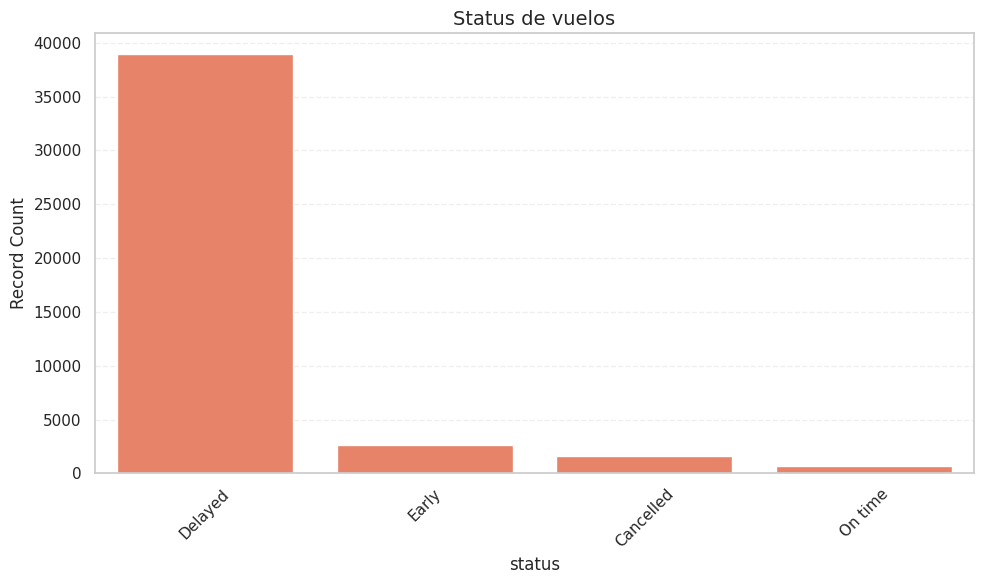

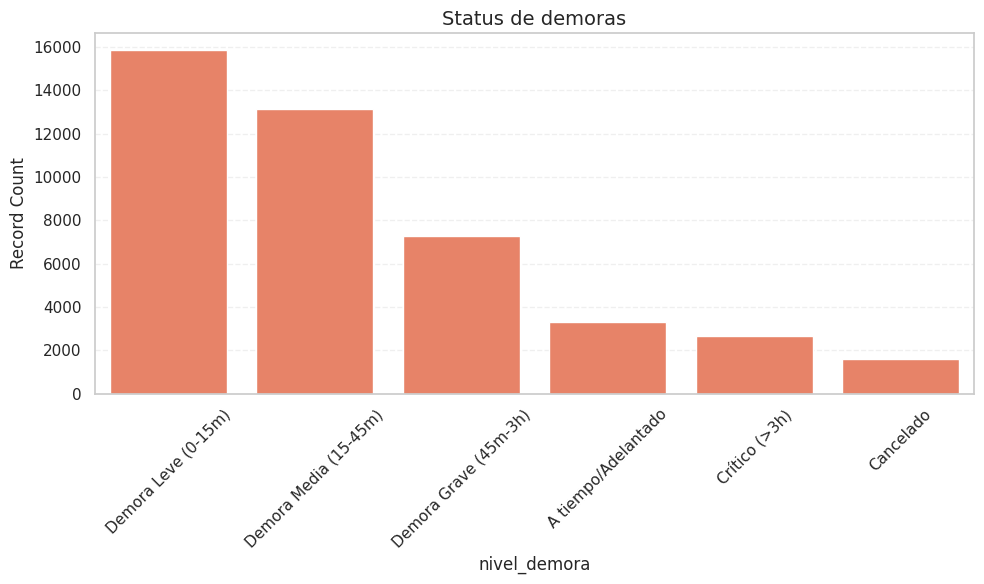

In [50]:
plot_frequencies(df, 'status', color=color_g, title='Status de vuelos')
plot_frequencies(df, 'nivel_demora', color=color_g, title='Status de demoras')

Se puede ver que la cantidad de vuelos con demora leve y media supera en gran proporción a los demas vuelos.
También se puede ver que los vuelos cancelados son inferiores a los vuelos con una demora "Crítico > 3h"

En el siguiente gráfico veremos como se distribuyen los datos según los minutos de demora.

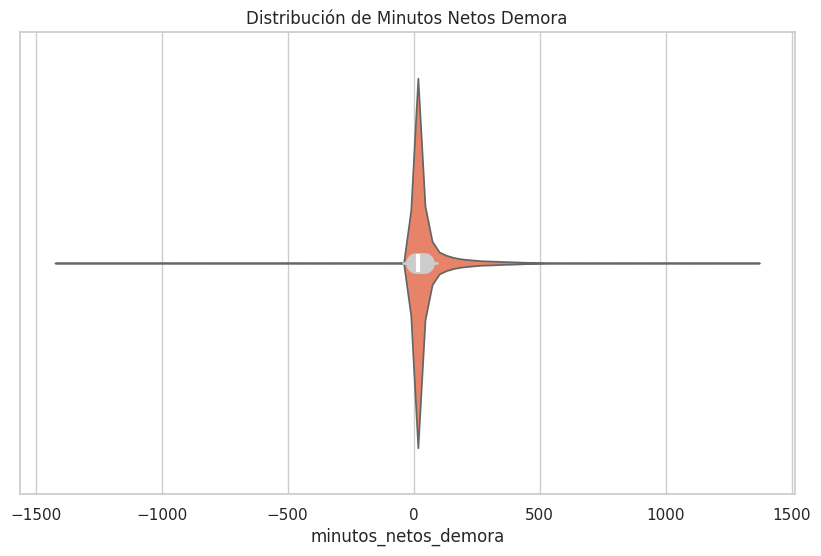

In [51]:
# show_distribution_violinplot(df)
show_distribution_violinplot(df, "minutos_netos_demora", color=color_g)

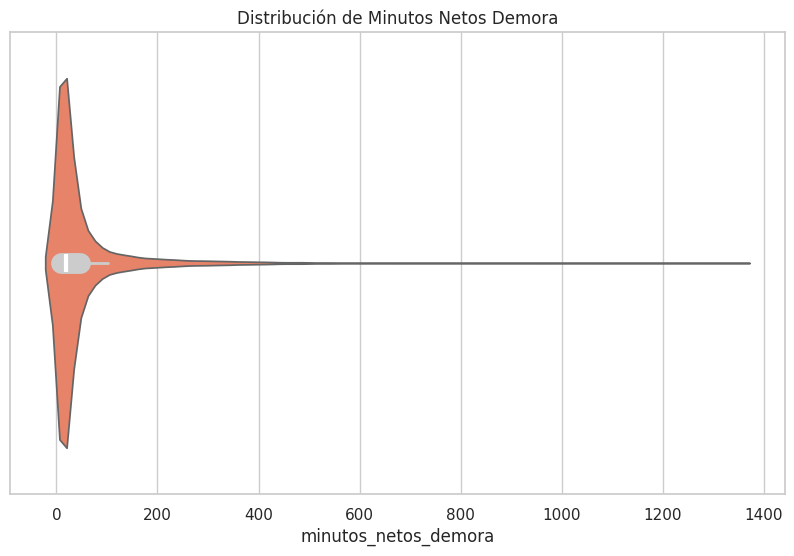

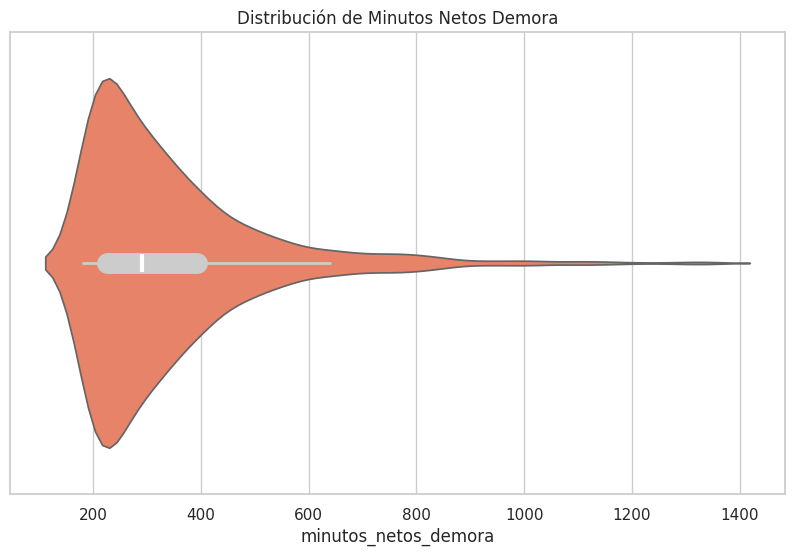

In [52]:
show_distribution_violinplot(df, "minutos_netos_demora", min_value=0)
show_distribution_violinplot(df, "minutos_netos_demora", min_value=180)


Con el gráfico de violinplot podemos ver cómo se distribuyen los valores de minutos de demora. El valor de 1400 equivalen a más de 23 horas de demora. La mayor concentración se encuentra entre los 0 minutos y los 400 minutos.

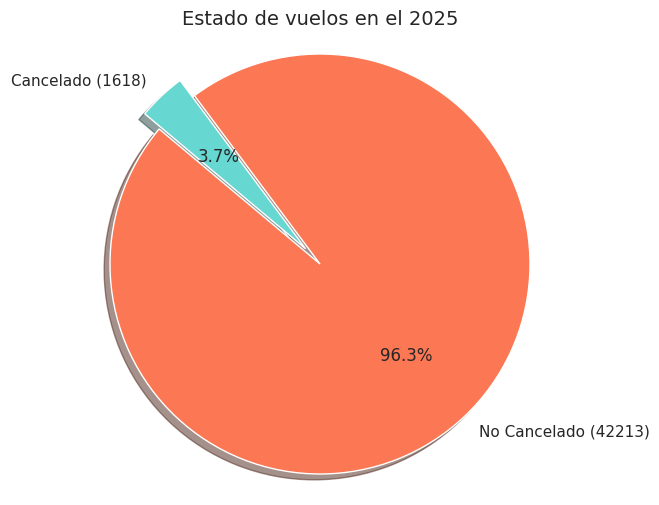

In [53]:
show_custom_pie(df, 'is_cancelled', labels=["No Cancelado", "Cancelado"], title="Estado de vuelos en el 2025", colors=paleta )

La cantidad de vuelos cancelados es mucho menor.

# Análisis Bivariado

Vamos a comparar las empresas "Jetsmart" y "Flybondi" como fue su desempeño en vuelos cancelados y con demoras. La evolución de mes a mes.

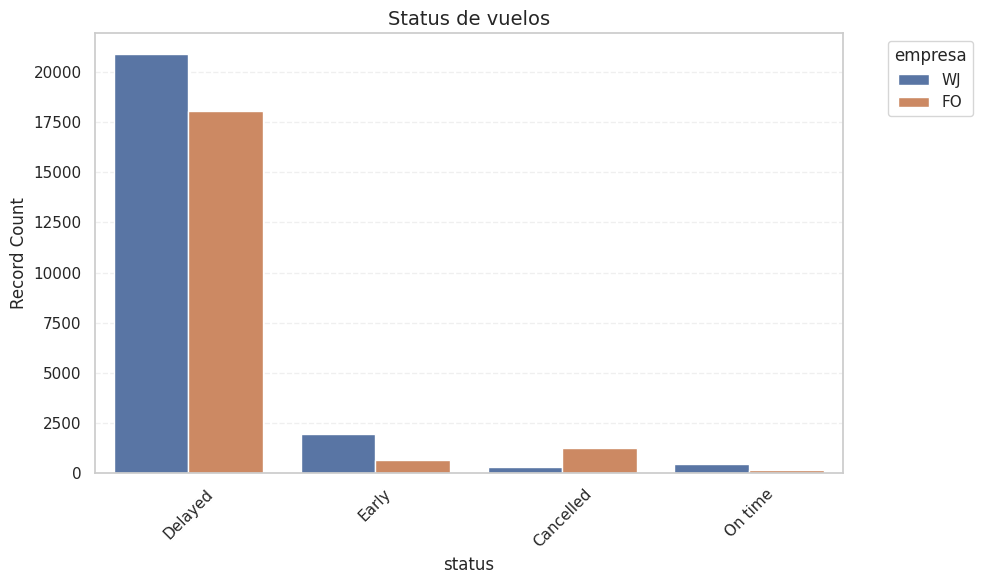

In [54]:
plot_frequencies(df, 'status', category="empresa", title='Status de vuelos')

Se puede ver que la empresa Jetsmart posee más retrasos en vuelos, pero en la empresa Flybondi posee mayor cantidad de vuelos cancelados.

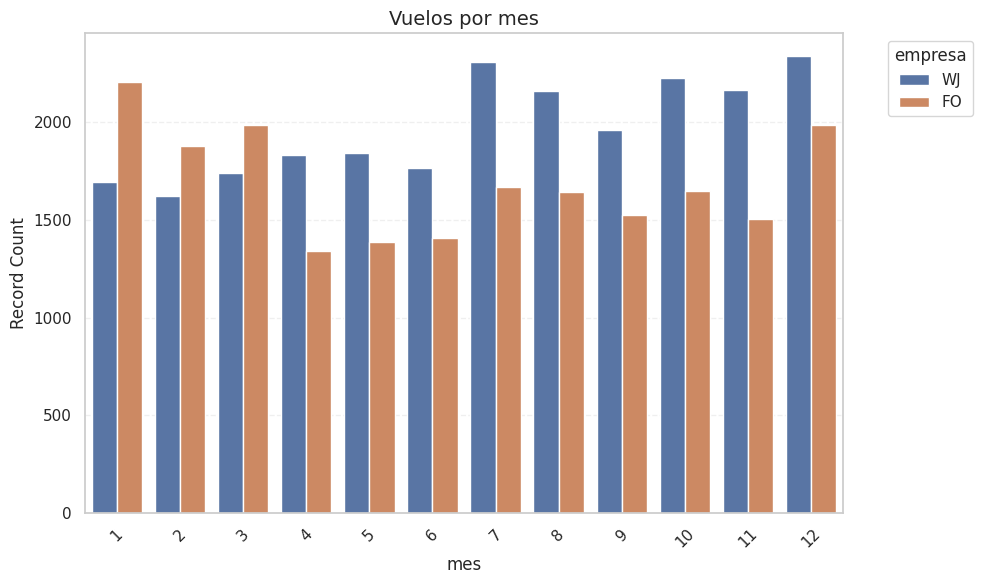

In [55]:
plot_frequencies(df, 'mes', category="empresa", title='Vuelos por mes', sort_by_index=True)

### Demoras de vuelos

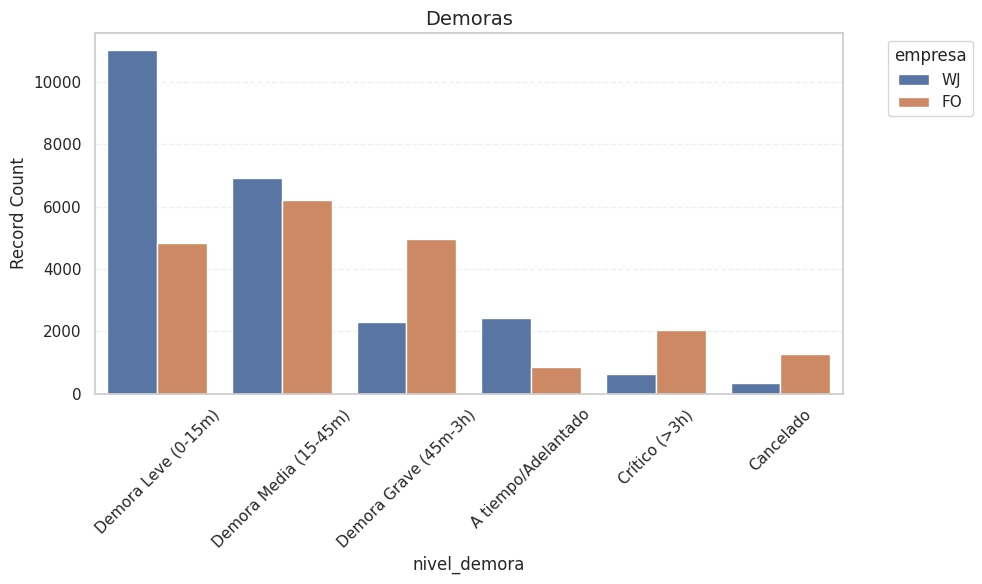

In [56]:
plot_frequencies(df, 'nivel_demora', category="empresa", title='Demoras')

La empresa de "Jetsmart" posee mayor cantidad de vuelos con Demora Leve y Demora Media. En cambio las demoras de más de 45 minutos se encuentra liderada por la empresa de Flybondi.

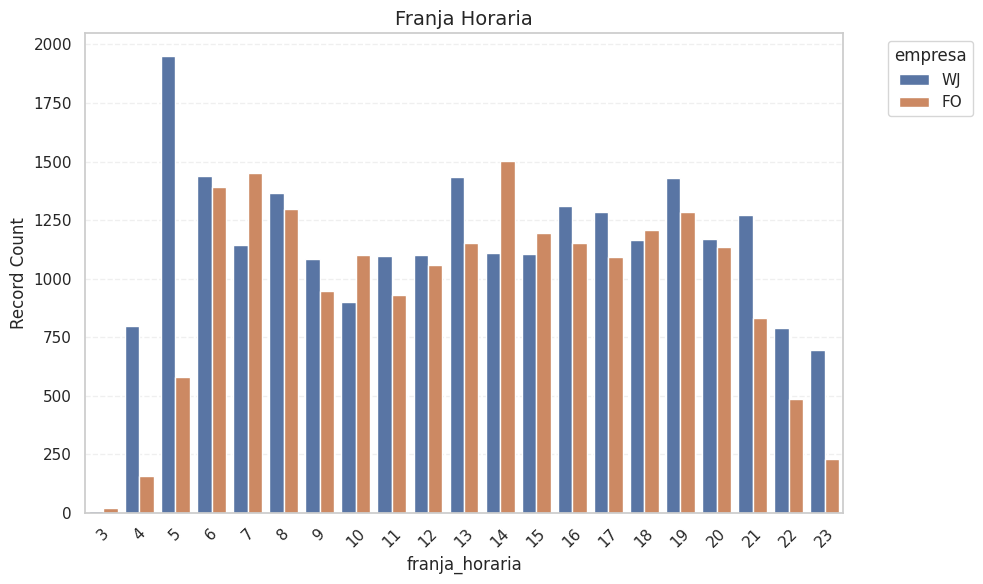

In [57]:
plot_frequencies(df, 'franja_horaria', category="empresa", title='Franja Horaria', sort_by_index=True)

A las 5 se encuentra la mayor cantidad de vuelos de la empresa "Jetsmart"

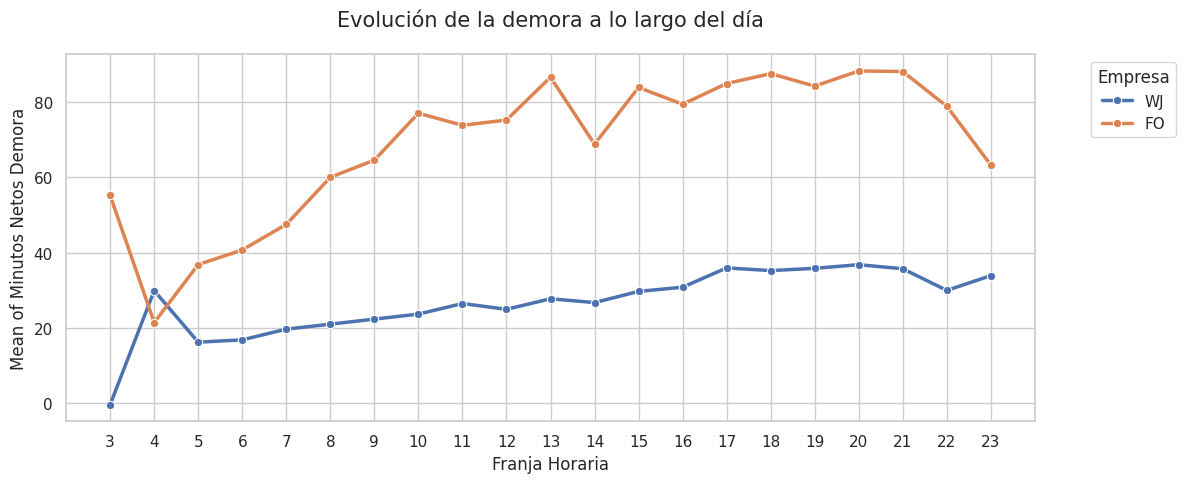

In [58]:
plot_evolution(df, 'franja_horaria', 'minutos_netos_demora', category="empresa", estimator='mean', title='Evolución de la demora a lo largo del día')


Alrededor de las 4 de la mañana se puede ver en la empresa de Flybondi tiene valores mínimos, ya más adelante la demora sigue creciendo, esto puede deberse a que cada vez se acumulan las demoras. En la empresa de Jetsmart tiene el primer máximo a las 4 am, pero luego se estabiliza esto puede deberse a que las demoras son leves, y no implica mucho retraso en los vuelos siguientes.

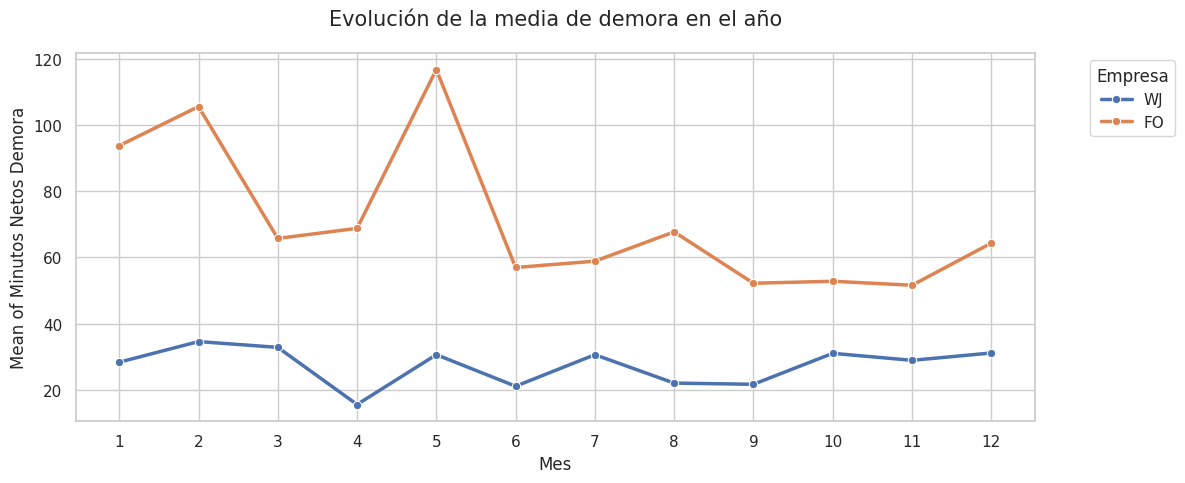

In [59]:
plot_evolution(df, 'mes', 'minutos_netos_demora', category="empresa", estimator='mean', title='Evolución de la media de demora en el año')


Viendo la evolución de la media de minutos de demora se puede ver que en el mes de enero, febrero y Mayo se encuentran los puntos más altos de la empresa de Flybondi.

De la empresa Jetsmart podemos observar que en el mes de abril posee valor mínimo de la media.

Se puede apreciar la diferencia entre las dos empresas, una posee una media de demora mayor. Esta información nos da una idea que al viajar con la primer empresa podremos tener una espera más larga.

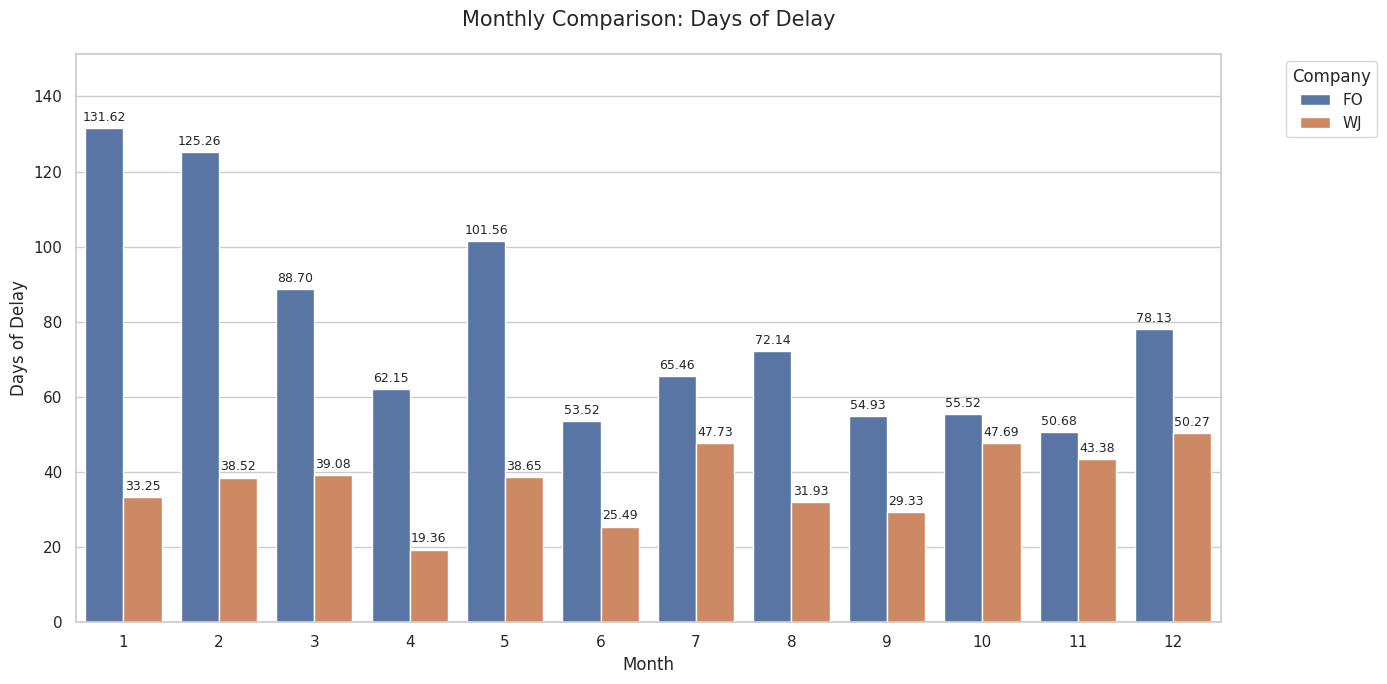

In [60]:
plot_temporal_impact(df,category="empresa", unit='days', show_labels=True)

El gráfico muestra que los usuarios de Flybondi perdieron mayor tiempo debido a las demoras que los usuarios de Jetsmart. El caso más notable se ve en el mes de enero en el que hay una diferencia equivalente a casi cien días.

Siguiendo con el gráfico de vuelos por mes, la primer empresa tiene mayor volumen de vuelos en los primeros meses. Las demoras pueden ser debido a la gran demanda de pasajes, y al demorarse los vuelos van arrastrando más tiempo de demora.

### Cancelaciones de vuelos

In [61]:
#graficar_cancelaciones(df, por_empresa=True)

Podemos visualizar dos picos grandes en el mes de abril y julio. Luego se puede ver que durante los meses de enero, febrero, agosto, noviembre y diciembre hay varios dias con muchas cancelaciones.

Vamos a ver en más detalle mes a mes, primero veremos los picos de cancelaciones y luego aquellos meses con cancelaciones.

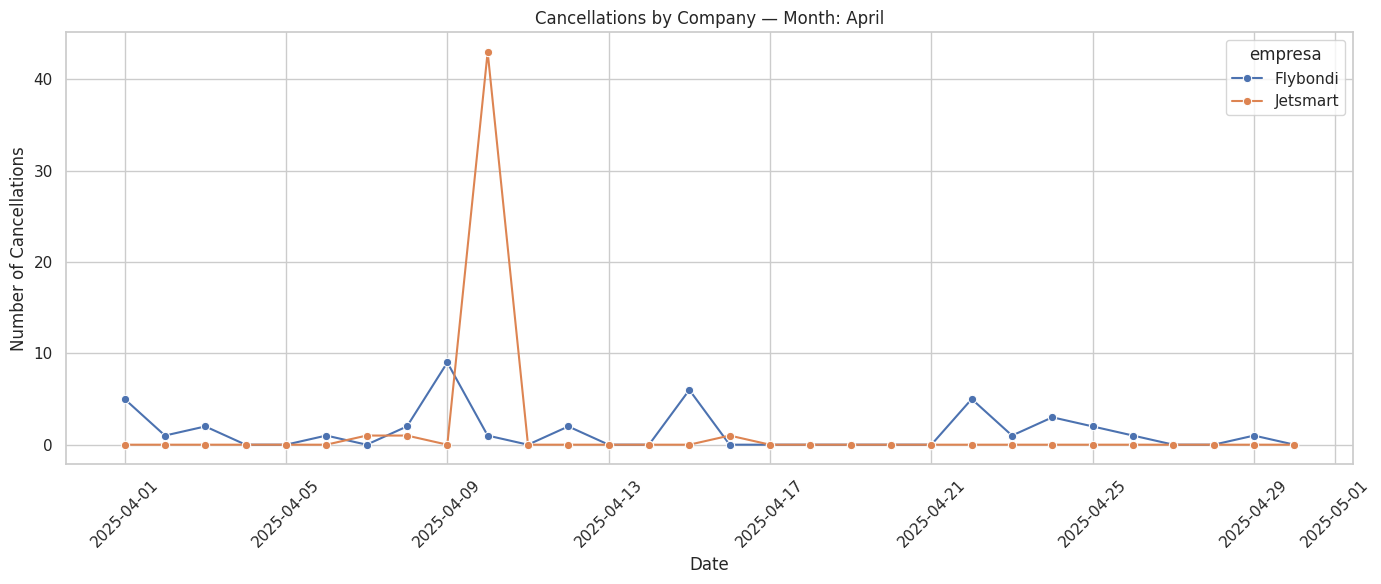

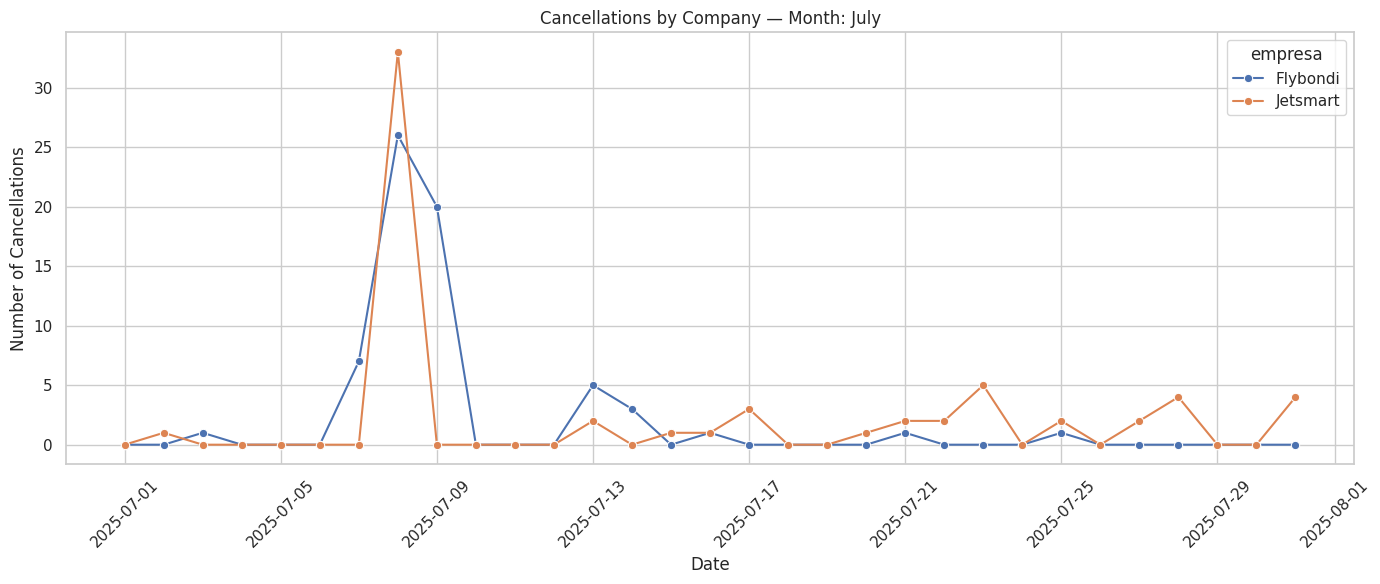

In [62]:
plot_cancellations(df, by_company=True, month=4)
plot_cancellations(df, by_company=True, month=7)


Se puede apreciar que los vuelos del 10 de abril se encuentran un pico de vuelos cancelados.
Buscando más información sobre el estado de los vuelos de esa fecha encontre que hubo un paro general en la Argentina afectando a los vuelos de la empresa.

Link https://www.infobae.com/economia/2025/04/08/paro-general-que-pasara-con-los-vuelos-este-jueves/

El dia 8 de julio las aerolíneas tuvieron que posponer y cancelar muchos vuelos debido a una niebla en los aeropuertos de Buenos Aires.

Este dato es importante a la hora de analizar las cancelaciones de vuelos, no es algo que se pueda preveer con mucha anticipación, siendo julio el mes de vacaciones de invierno la cantidad de vuelos es mayor.

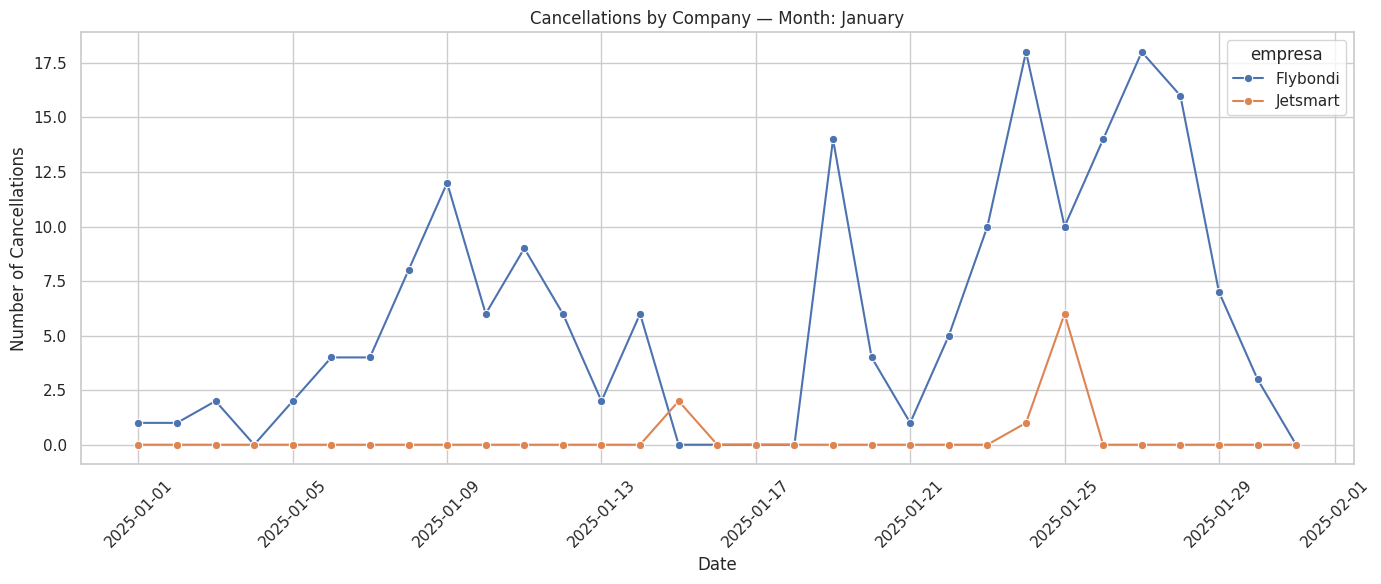

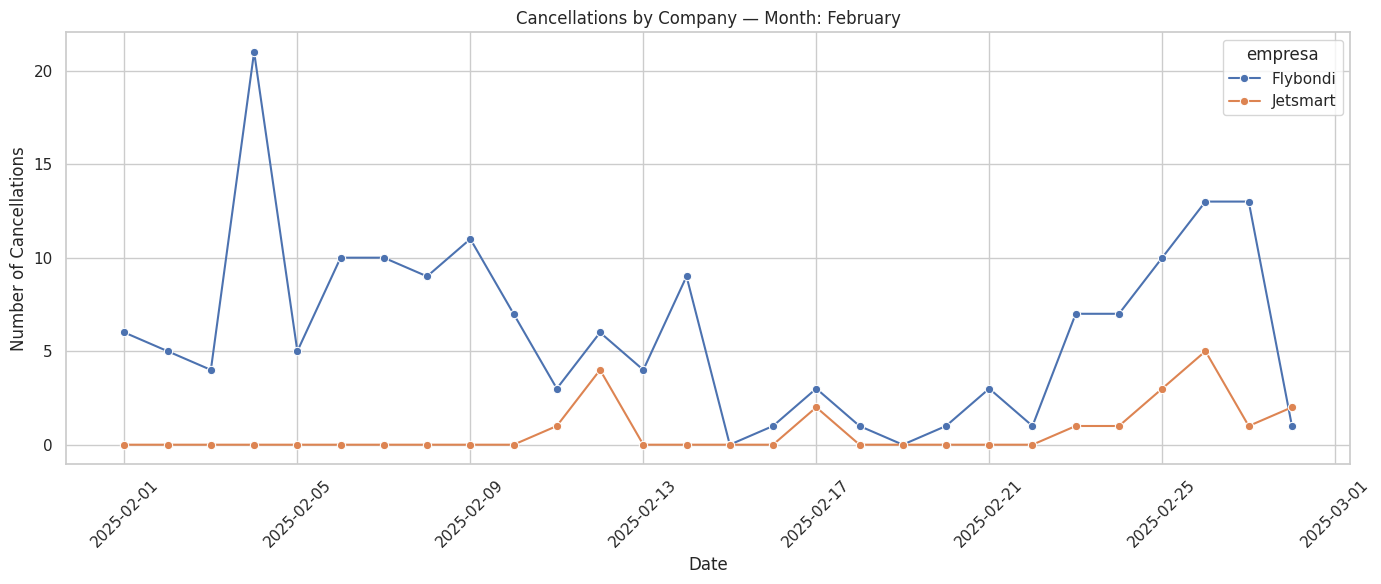

In [63]:
plot_cancellations(df, by_company=True, month=1)
plot_cancellations(df, by_company=True, month=2)


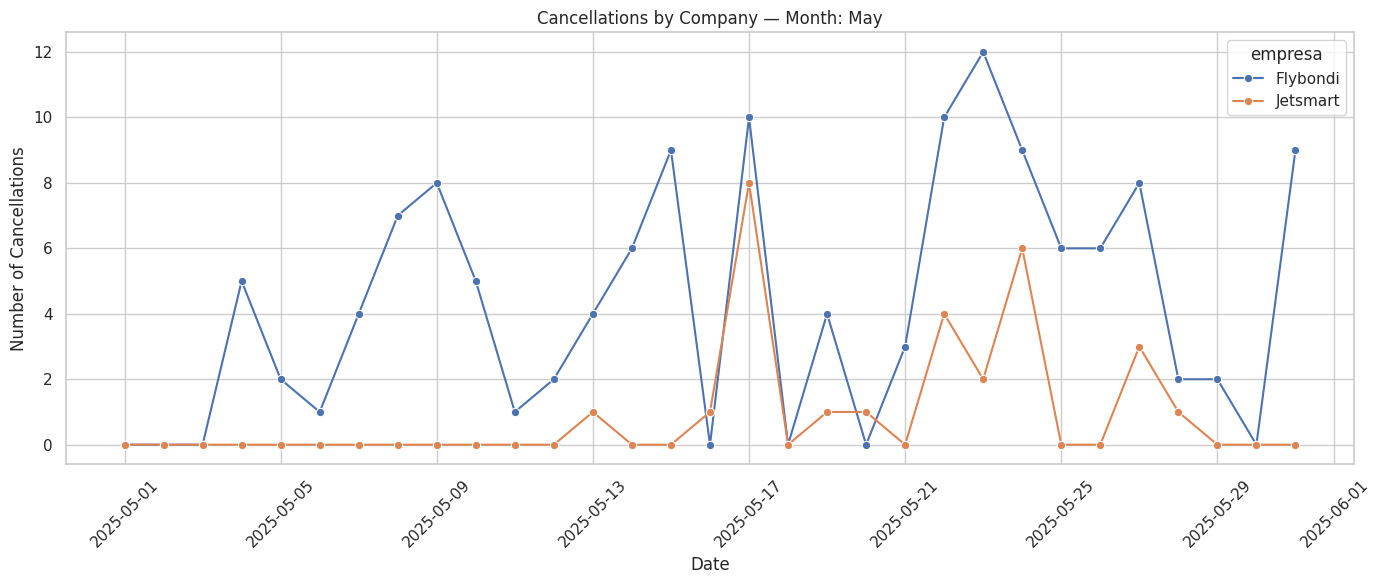

In [64]:
plot_cancellations(df, by_company=True, month=5)


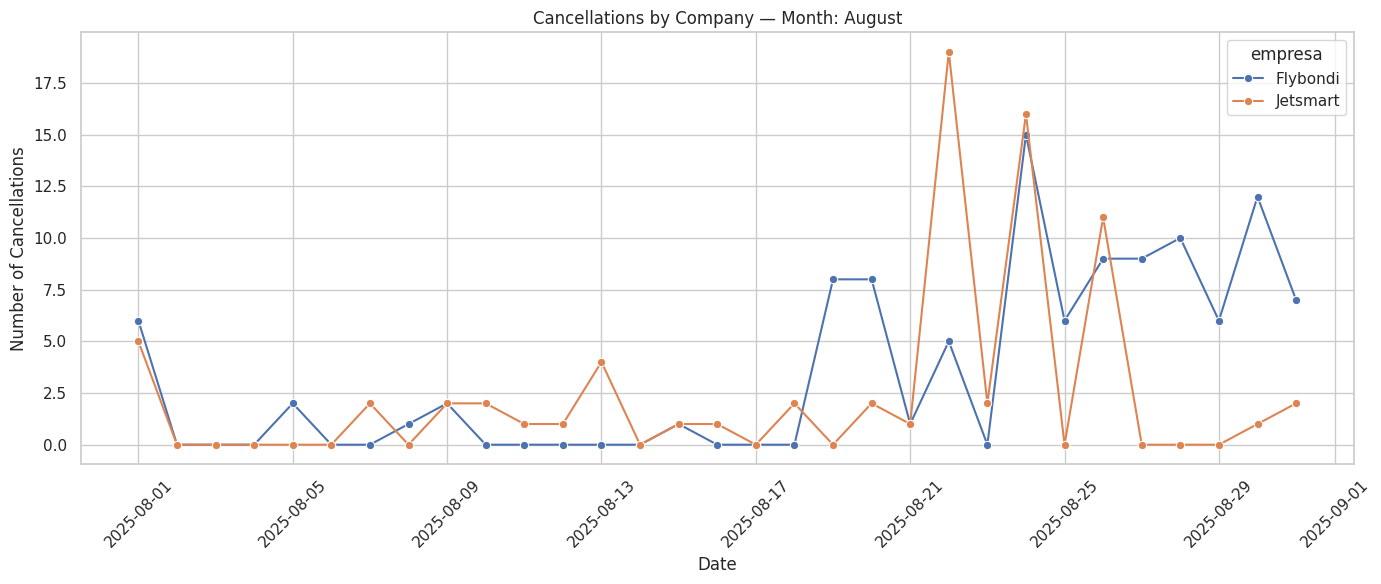

In [65]:
plot_cancellations(df, by_company=True, month=8)


El 22-08 hubo paro de controladores aéreos.
https://www.lanacion.com.ar/sociedad/comenzo-el-paro-de-controladores-aereos-en-los-aeropuertos-de-todo-el-pais-nid22082025/

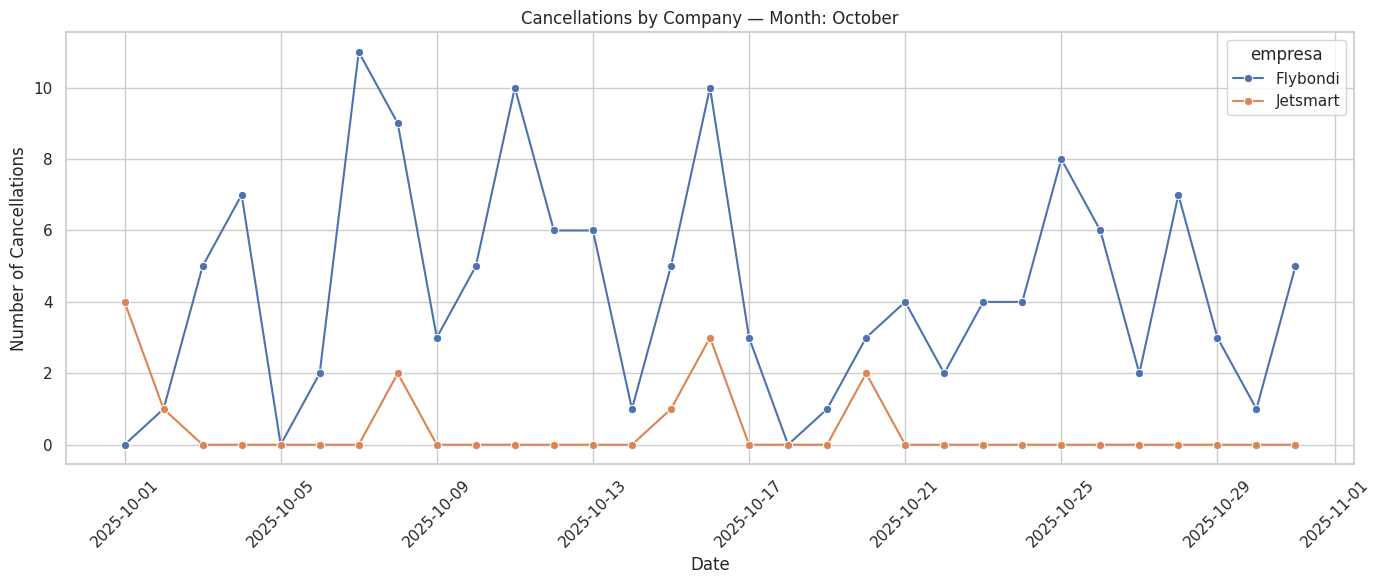

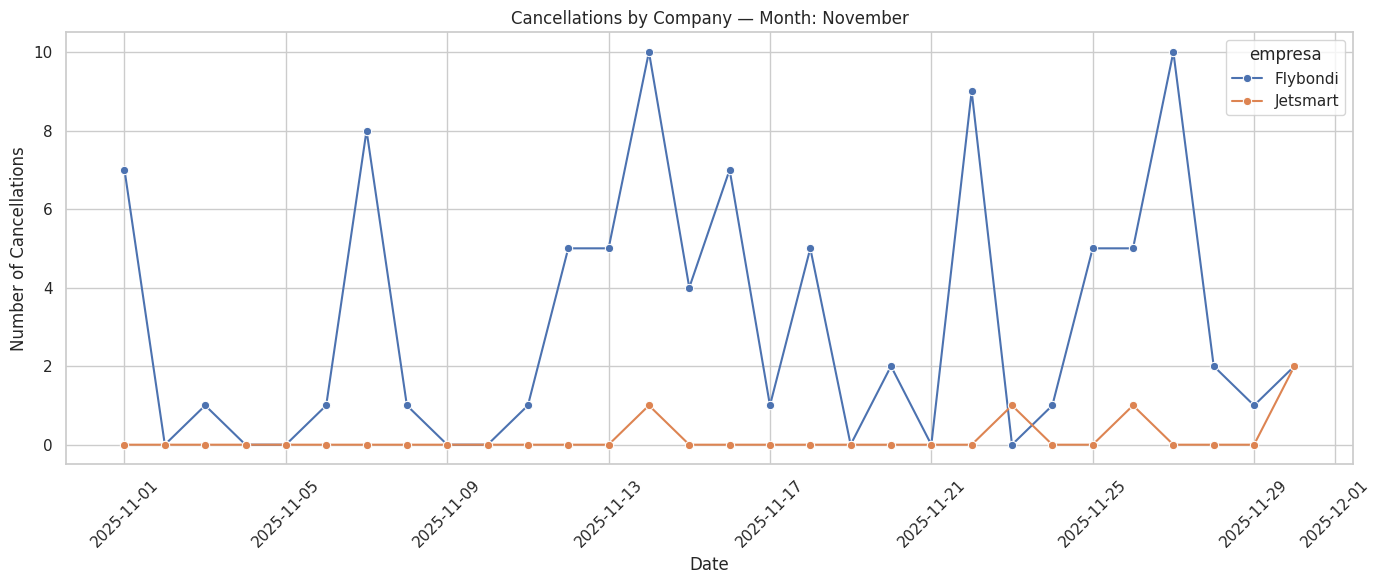

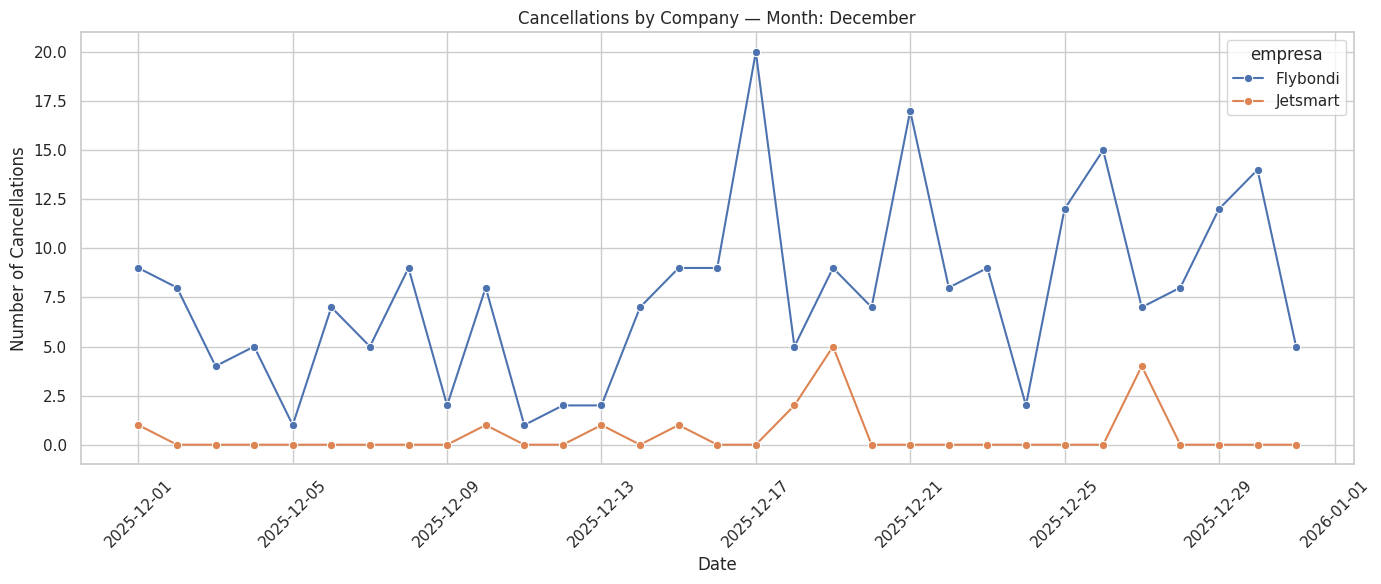

In [66]:
plot_cancellations(df, by_company=True, month=10)
plot_cancellations(df, by_company=True, month=11)
plot_cancellations(df, by_company=True, month=12)


17-12 paro de controladores áereos https://www.pagina12.com.ar/2025/12/17/paro-de-controladores-aereos-demoras-y-reprogramaciones-en-los-vuelos/

En el último trimestre del año 2025 se puede ver que las cancelaciones de Flybondi superan a los de Jetsmart.

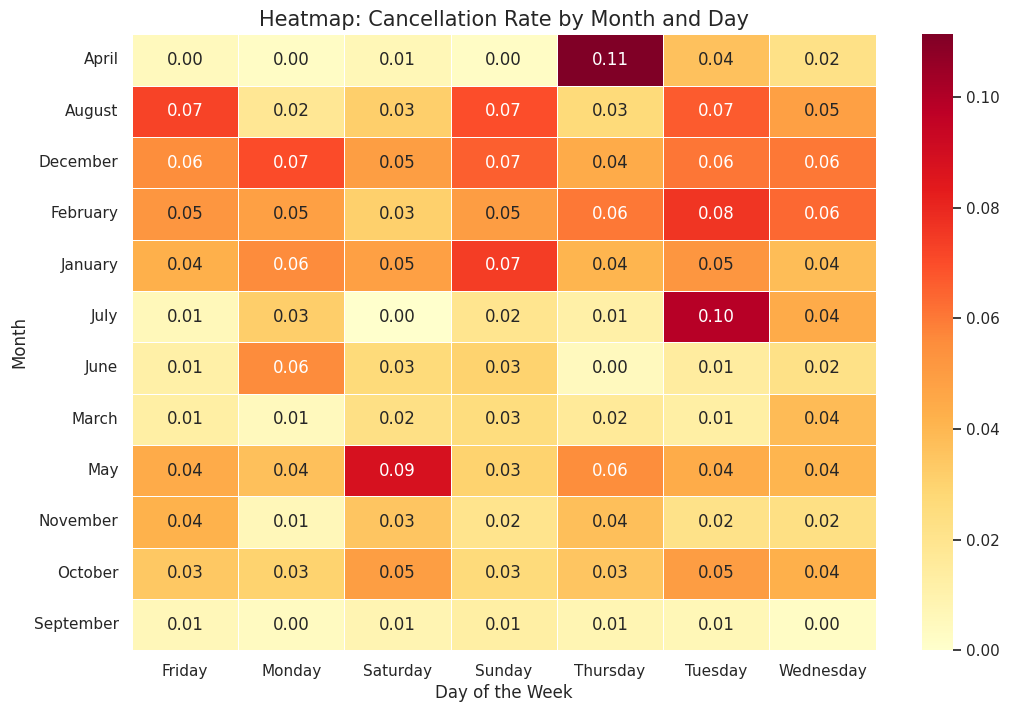

In [72]:
plot_cancellations_heatmap(df)

### Reporte final

In [68]:
# 1. Creamos el nuevo dataset agrupado
df_reporte = df.groupby('empresa').agg(
    total_vuelos=('status', 'count'),
    cancelaciones=('status', lambda x: (x == 'Cancelled').sum()),
    total_minutos_demora=('minutos_netos_demora', 'sum')
).reset_index()

# 2. Calculamos los días perdidos
# Fórmula: Minutos / 60 (horas) / 24 (día)
df_reporte['dias_perdidos'] = (df_reporte['total_minutos_demora'] / 1440).round(2)

# 3. Opcional: Tasa de cancelación para dar contexto
df_reporte['tasa_cancelacion'] = (df_reporte['cancelaciones'] / df_reporte['total_vuelos'] * 100).round(2)

# Mostramos el resultado
print(df_reporte[['empresa', 'total_vuelos', 'cancelaciones', 'dias_perdidos', 'tasa_cancelacion']])

  empresa  total_vuelos  cancelaciones  dias_perdidos  tasa_cancelacion
0      FO         20186           1278         939.68              6.33
1      WJ         23645            340         444.70              1.44


In [69]:
# Agrupamos por ruta (Origen-Destino)
ruta_critica = df.groupby('Ruta').agg({
    'minutos_netos_demora': 'mean',
    'is_cancelled': 'mean',
    'empresa': 'count' # Para saber cuántos vuelos totales tiene esa ruta
}).rename(columns={'empresa': 'total_vuelos'})

# Filtramos rutas con un volumen mínimo de vuelos para que el dato sea estadísticamente relevante
ruta_critica = ruta_critica[ruta_critica['total_vuelos'] > 10].sort_values(by='minutos_netos_demora', ascending=False)

print(ruta_critica.head(10))

                          minutos_netos_demora  is_cancelled  total_vuelos
Ruta                                                                      
Posadas → Ezeiza                    157.866667      0.090909            33
Sgo. del Estero → Ezeiza            118.781250      0.000000            32
Mendoza → Córdoba                   118.181818      0.241379            29
Córdoba → Mendoza                   104.583333      0.225806            31
San Juan → Ezeiza                   100.121951      0.046512            43
Córdoba → Ezeiza                     99.269737      0.044025           159
Jujuy → Ezeiza                       95.881410      0.057402           331
Córdoba → Iguazú                     85.500000      0.000000            16
San Juan → Aeroparque                83.849741      0.102326           215
Aeroparque → Jujuy                   83.055394      0.055096           363


## Conclusión

Luego de analizar los vuelos del dataset, y ver que dias hubieron mayor cantidad de cancelaciones y buscar el motivo, hay algo que no se estaba considerando en el dataset para el próximo paso que es el de paro de trabajadores del sector aeropuertario.

Se debe trabajar con esa información para que un modelo predictivo sea eficiente, para esto voy a sumar la columna flag es_paro con valores booleanos.